In [11]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pathlib
from collections import Counter

In [4]:
test_data = pd.read_csv("datasets/anita_video_dataset.csv")
X_test = test_data.iloc[:, :63].values
y_test = test_data.iloc[:, 63:].values

In [6]:
@keras.saving.register_keras_serializable()
def focal_loss_fixed(y_true, y_pred):
    """Focal loss for multi-classification
    FL(p_t)=-alpha * (1-p_t)^gamma * log(p_t)
    where p = softmax score, t = true class
    """
    epsilon = 1.e-9
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    y_true = tf.cast(y_true, tf.float32)

    model_out = tf.add(y_pred, epsilon)
    ce = tf.multiply(y_true, -tf.math.log(model_out))
    weight = tf.multiply(y_true, tf.pow(tf.subtract(1., model_out), 2.))
    fl = tf.multiply(4., tf.multiply(weight, ce))
    reduced_fl = tf.reduce_max(fl, axis=1)
    return tf.reduce_mean(reduced_fl)

In [9]:
model = load_model("models/pawel_anita_love_13.keras", custom_objects={'focal_loss_fixed': focal_loss_fixed})
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm_dt = confusion_matrix(y_true, y_pred_classes)
cm_dt_normalized = cm_dt.astype('float') / 271
cm_dt_normalized_rounded = cm_dt_normalized.round(2)

204/204 [==============================] - 0s 1ms/step


Text(0.5, 1.0, 'Macierz Pomyłek')

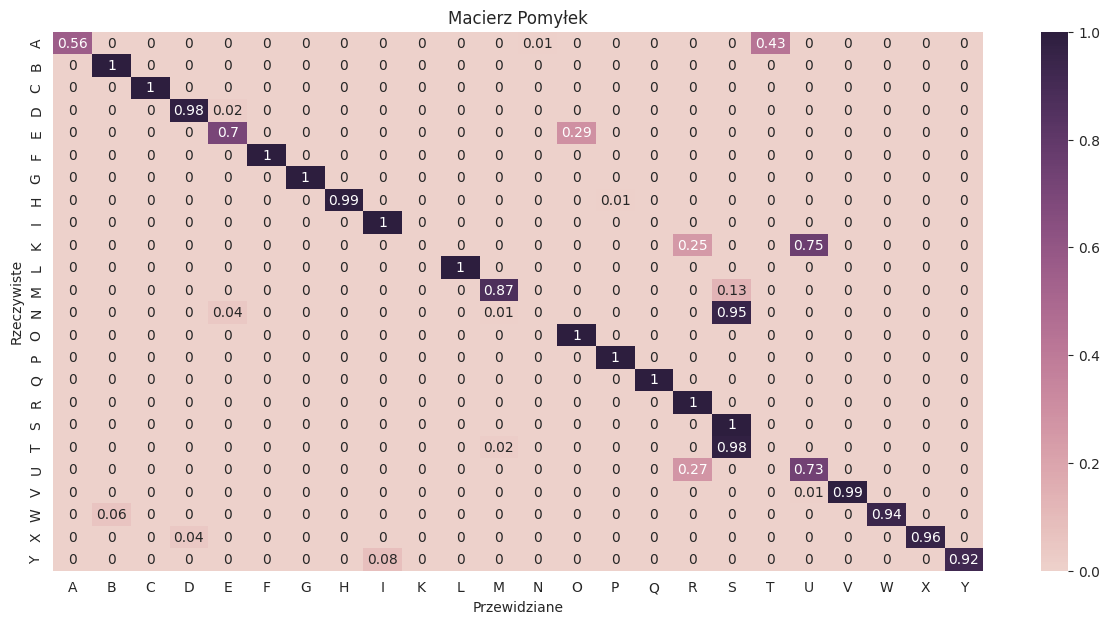

In [12]:
plt.figure(figsize=(15,7))
klasy = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
sns.heatmap(cm_dt_normalized_rounded, annot=True, fmt='g', cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=klasy, yticklabels=klasy)
plt.plot()
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz Pomyłek')

In [ ]:
models_cm_loss = Counter()
for saved_model in pathlib.Path("models").iterdir():
    print(str(saved_model))
    if str(saved_model).split(".")[1] == "keras":
        model = load_model(str(saved_model))
    else:
        model = joblib.load(str(saved_model))
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm_dt = confusion_matrix(y_true, y_pred_classes)
    cm_dt_normalized = cm_dt.astype('float') / 271
    cm_dt_normalized_rounded = cm_dt_normalized.round(2)
    for i in range(24):
        models_cm_loss[saved_model.name] += 1 - cm_dt_normalized_rounded[i][i]
models_cm_loss

In [27]:
from src.video_transcription.points_normalization import normalize_lists
from src.letter_detection.letter_detection_models import AnalysisModel

analysis_model = AnalysisModel()

LETTERS = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K',
           'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U',
           'V', 'W', 'X', 'Y']

cm_analysis = np.zeros((24, 24))
for i in range(len(y_test)):
    xyz_points = X_test[i]
    x_points = xyz_points[:21]
    y_points = xyz_points[21:42]
    z_points = xyz_points[42:]
    x_normalized, y_normalized, is_vertical = normalize_lists(x_points, y_points)
    letter = analysis_model.predict(x_normalized, y_normalized, z_points, is_vertical)
    if letter:
        cm_analysis[LETTERS.index(letter)][np.argmax(y_test[i])] += 1

cm_analysis_normalized = cm_analysis.astype('float') / 271
cm_analysis_normalized_rounded = cm_analysis_normalized.round(2)
for i in range(24):
    models_cm_loss["analysis_model"] += 1 - cm_analysis_normalized_rounded[i][i]

In [28]:
models_cm_loss
# {
#     'analysis_model': 18.080000000000002,
#     'decision_tree_entropy_no_augmentation.pkl': 11.68,
#     'decision_tree_gini_no_augmentation.pkl': 11.389999999999999,
#     'decision_tree_entropy_123.pkl': 11.32,
#     'decision_tree_log_loss_no_augmentation.pkl': 11.19,
#     'decision_tree_gini_augmentation_data_123.pkl': 11.13,
#     'decision_tree_log_loss_123.pkl': 11.06,
#     'decision_tree_log_loss_12.pkl': 10.34,
#     'decision_tree_entropy_12.pkl': 10.16,
#     'decision_tree_gini_augmentation_data_12.pkl': 10.120000000000001,
#     'pawel_anita_love_7.keras': 7.6,
#     'pawel_anita_love_11.keras': 5.760000000000001,
#     'pawel_anita_love_12.keras': 5.180000000000001,
#     'pawel_anita_love_10.keras': 4.650000000000001,
#     'pawel_anita_love_13.keras': 4.36,
#     'pawel_anita_love_9.keras': 4.28,
#     'pawel_anita_love_8.keras': 3.4699999999999998
# }

Counter({'analysis_model': 18.080000000000002,
         'decision_tree_entropy_no_augmentation.pkl': 11.68,
         'decision_tree_gini_no_augmentation.pkl': 11.389999999999999,
         'decision_tree_entropy_123.pkl': 11.32,
         'decision_tree_log_loss_no_augmentation.pkl': 11.19,
         'decision_tree_gini_augmentation_data_123.pkl': 11.13,
         'decision_tree_log_loss_123.pkl': 11.06,
         'decision_tree_log_loss_12.pkl': 10.34,
         'decision_tree_entropy_12.pkl': 10.16,
         'decision_tree_gini_augmentation_data_12.pkl': 10.120000000000001,
         'pawel_anita_love_7.keras': 7.6,
         'pawel_anita_love_11.keras': 5.760000000000001,
         'pawel_anita_love_12.keras': 5.180000000000001,
         'pawel_anita_love_10.keras': 4.650000000000001,
         'pawel_anita_love_13.keras': 4.36,
         'pawel_anita_love_9.keras': 4.28,
         'pawel_anita_love_8.keras': 3.4699999999999998})

In [1]:
cm = {'analysis_model': 18,
         'decision_tree_entropy_no_augmentation.pkl': 11.68,
         'decision_tree_gini_no_augmentation.pkl': 11.39,
         'decision_tree_entropy_123.pkl': 11.32,
         'decision_tree_log_loss_no_augmentation.pkl': 11.19,
         'decision_tree_gini_augmentation_data_123.pkl': 11.13,
         'decision_tree_log_loss_123.pkl': 11.06,
         'decision_tree_log_loss_12.pkl': 10.34,
         'decision_tree_entropy_12.pkl': 10.16,
         'decision_tree_gini_augmentation_data_12.pkl': 10.12,
         'pawel_anita_love_7.keras': 7.6,
         'pawel_anita_love_11.keras': 5.76,
         'pawel_anita_love_12.keras': 5.18,
         'pawel_anita_love_10.keras': 4.65,
         'pawel_anita_love_13.keras': 4.36,
         'pawel_anita_love_9.keras': 4.28,
         'pawel_anita_love_8.keras': 3.47}


{'analysis_model': 18,
 'decision_tree_entropy_no_augmentation.pkl': 11.68,
 'decision_tree_gini_no_augmentation.pkl': 11.39,
 'decision_tree_entropy_123.pkl': 11.32,
 'decision_tree_log_loss_no_augmentation.pkl': 11.19,
 'decision_tree_gini_augmentation_data_123.pkl': 11.13,
 'decision_tree_log_loss_123.pkl': 11.06,
 'decision_tree_log_loss_12.pkl': 10.34,
 'decision_tree_entropy_12.pkl': 10.16,
 'decision_tree_gini_augmentation_data_12.pkl': 10.12,
 'pawel_anita_love_7.keras': 7.6,
 'pawel_anita_love_11.keras': 5.76,
 'pawel_anita_love_12.keras': 5.18,
 'pawel_anita_love_10.keras': 4.65,
 'pawel_anita_love_13.keras': 4.36,
 'pawel_anita_love_9.keras': 4.28,
 'pawel_anita_love_8.keras': 3.47}

In [ ]:
     SN, Model bazowy, augmentacja danych z rozstrzałem 0.01, 0.02 & 3.47 \\
     SN, Model bazowy, augmentacja danych z rozstrzałem 0.01, 0.02, 0.03 & 4.28 \\
     SN, Model z funkcją straty \textit{focal loss} & 4.36 \\
     SN, Model bazowy, augmentacja danych  oś XY: 0.01, 0.02, 0.03, oś Z: 0.01 & 4.65 \\
     SN, Model z funkcją \textit{sigmoid} jako funkcja aktywacji na ostatniej warstwie & 5.18 \\
     SN, Model bazowy, rozszerzona augmentacja danych o mieszane rozstrzały & 5.76 \\
     SN, Model bazowy, brak augmentacji & 7.60 \\
     DD, Entropy, random, augmentacja danych, rozstrzał 0.01, 0.02 & 8.48 \\
     DD, Gini, random, augmentacja danych, rozstrzał 0.01, 0.02 & 8.66 \\
     DD, Gini, random, augmentacja danych, rozstrzał 0.01, 0.02, 0.03 & 9.06 \\
     DD, Log-loss, random, augmentacja danych, rozstrzał 0.01, 0.02 & 9.49 \\
     DD, Log-loss, random, brak augmentacja danych & 9.62 \\
     DD, Entropy, random, augmentacja danych, rozstrzał 0.01, 0.02, 0.03 & 9.89 \\
     DD, Log-loss, random, augmentacja danych, rozstrzał 0.01, 0.02, 0.03 & 10.06 \\
     DD, Gini, best, augmentacja danych, rozstrzał 0.01, 0.02 & 10.12 \\
     DD, Entropy, best, augmentacja danych, rozstrzał 0.01, 0.02 & 10.16 \\
     DD, Log-loss, best, augmentacja danych, rozstrzał 0.01, 0.02 & 10.34 \\
     DD, Entropy, random, brak augmentacji danych & 10.076 \\
     DD, Gini, random, brak augmentacji danych & 10.096 \\
     DD, Log-loss, best, augmentacja danych, rozstrzał 0.01, 0.02, 0.03 & 11.06 \\
     DD, Gini, best, augmentacja danych, rozstrzał 0.01, 0.02, 0.03 & 11.13 \\
     DD, Log-loss, best, brak augmentacja danych & 11.19 \\
     DD, Entropy, best, augmentacja danych, rozstrzał 0.01, 0.02, 0.03 & 11.32 \\
     DD, Gini, best, brak augmentacji danych & 11.39 \\
     DD, Entropy, best, brak augmentacji danych & 11.68 \\
     Model analityczny na danych treningowych & 12.59 \\
     Model analityczny na danych testowych & 18.08 \\